In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/nfs/home/svu/e1498138/localgit/FEWNEW/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5 #scale by 2-3x
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")


# S schedule: jump to next S after 10000 iters of no improvement, consistent across all stages
S_schedule     = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
stuck_iters    = 10000  # iters of no improvement before jump/stop

# annealing dict
anneal_state = {
    'S':              S_schedule[0],       # start
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ])) * anneal_state['S']
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


Using dt=10s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 1539.1741
Setting up log_density and prior functions...


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_noise/int_3mth_noise_6'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.78018244,  0.73533365,  0.23492913,  0.35100383,  0.85103773],
        [ 0.72474559,  0.63312703,  0.91999526, -0.3664667 ,  0.33012038],
        [ 0.66318761,  0.54093122,  0.6155213 ,  0.7520317 ,  0.92885842],
        ...,
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]],
       shape=(300000, 5))]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([0.41844464,       -inf, 0.41218689, ..., 0.        , 0.        ,
        0.        ], shape=(300000,))]

In [7]:
sampler.now_covariances

[array([[ 0.00057309,  0.00039618,  0.00149467, -0.00186219, -0.00049933],
        [ 0.00039618,  0.00064673,  0.00080351, -0.00101211, -0.00066104],
        [ 0.00149467,  0.00080351,  0.00404146, -0.00502756, -0.00110772],
        [-0.00186219, -0.00101211, -0.00502756,  0.00625504,  0.00138944],
        [-0.00049933, -0.00066104, -0.00110772,  0.00138944,  0.00070281]])]

In [8]:
np.argmax(logden_list)

np.int64(120190)

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.06988826, 1.03916784, 0.58911287, 9.32763545, 0.44145466]])

In [10]:
log_density(maxld_pt1)

array([0.6274657])

In [11]:
log_density([param_true])

array([0.86128662])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[np.float64(6.0), np.float64(1.0), 0.7, 9, 0.4]

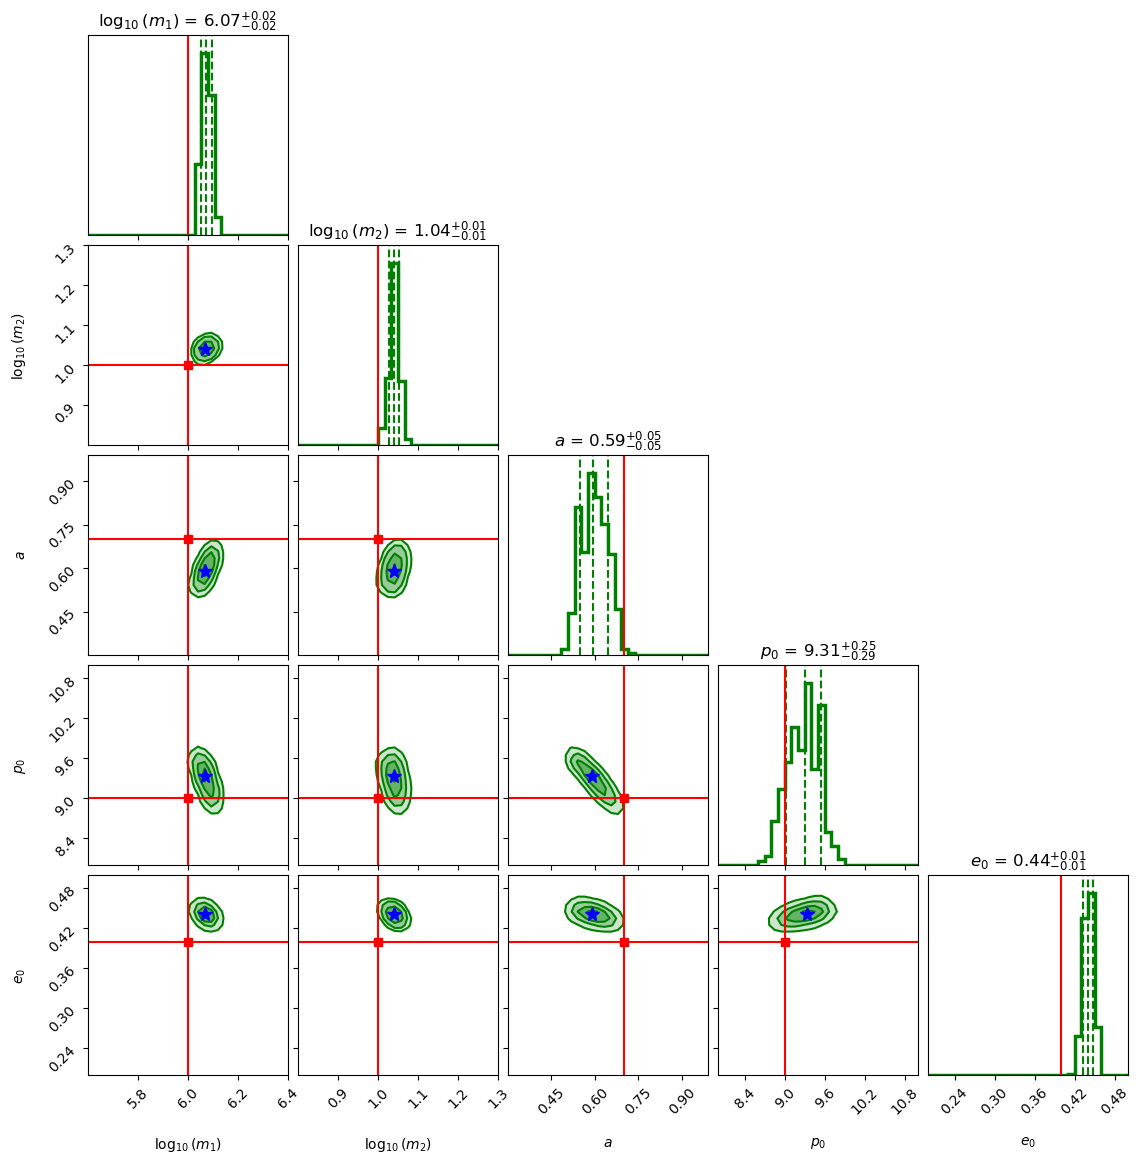

In [27]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges,
    # levels=(1-np.exp(-0.5*np.array([1,2,3,4])**2)).tolist()
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 255.3  (0.17% of N=150001)


In [28]:
import numpy as np

# samples from sampler (shape: N x 5)
# true params
true_pt = np.array([6.0, 1.0, 0.7, 9.0, 0.4])

# posterior mean and covariance from samples
mu = np.mean(samples, axis=0)
cov = np.cov(samples.T)

delta = true_pt - mu
mahal = np.sqrt(delta @ np.linalg.inv(cov) @ delta)
print(f"Mahalanobis distance: {mahal:.2f} sigma")

# per-param residuals in units of marginal sigma
sigmas = np.std(samples, axis=0)
print("Per-param (true - mean) / std:")
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for name, d, s in zip(param_names, delta, sigmas):
    print(f"  {name}: {d/s:+.2f} sigma")


Mahalanobis distance: 0.52 sigma
Per-param (true - mean) / std:
  logm1: -0.34 sigma
  logm2: -0.24 sigma
  a: +0.15 sigma
  p0: -0.25 sigma
  e0: -0.04 sigma


In [33]:
mu_center=[6.06988826, 1.03916784, 0.58911287, 9.32763545, 0.44145466]

# connection plot

In [16]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.06988826, 1.03916784, 0.58911287, 9.32763545, 0.44145466]])

In [17]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [18]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [19]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [20]:
logden_theory_proc1

array([0.6274657 , 0.29100472, 0.31590655, 0.35044736, 0.40299769,
       0.41534184, 0.26753411, 0.39363526, 0.29474158, 0.27921644,
       0.38741564, 0.30946915, 0.31012297, 0.33652921, 0.47487752,
       0.32062263, 0.36072829, 0.28381457, 0.25312312, 0.37431338,
       0.3443822 , 0.3354832 , 0.32327142, 0.34489114, 0.32297993,
       0.32533192, 0.35914544, 0.26645101, 0.35279969, 0.33570642,
       0.27655107, 0.33667432, 0.26900225, 0.30922334, 0.28148593,
       0.2611255 , 0.29541403, 0.30420751, 0.33629367, 0.28845088,
       0.23996661, 0.28533551, 0.26957487, 0.32495758, 0.29276018,
       0.31390106, 0.25730927, 0.38557795, 0.31028632, 0.86128662])

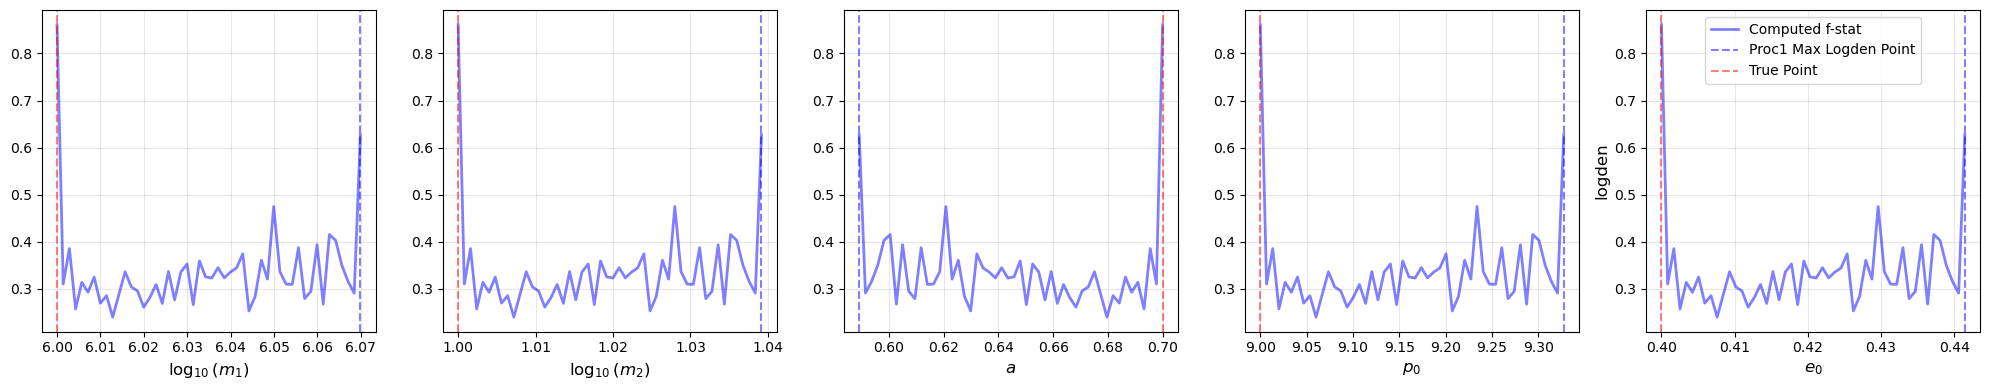

In [21]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


SNR T=6mth (time-max): 2175.8480
T=3mth at true: 0.8613
T=6mth at true: 14.2387
T=3mth at true: 0.8613
T=6mth at true: 14.2387


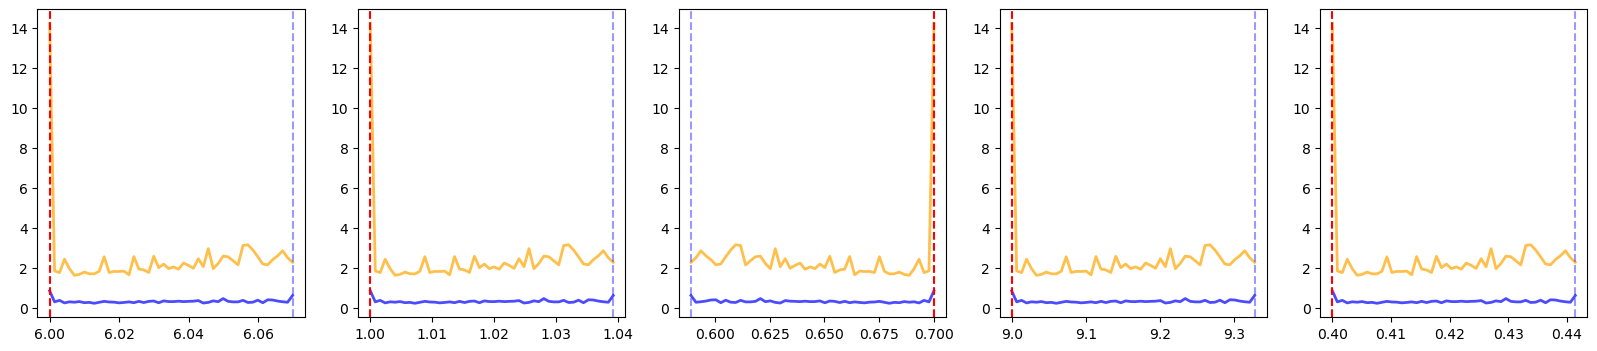

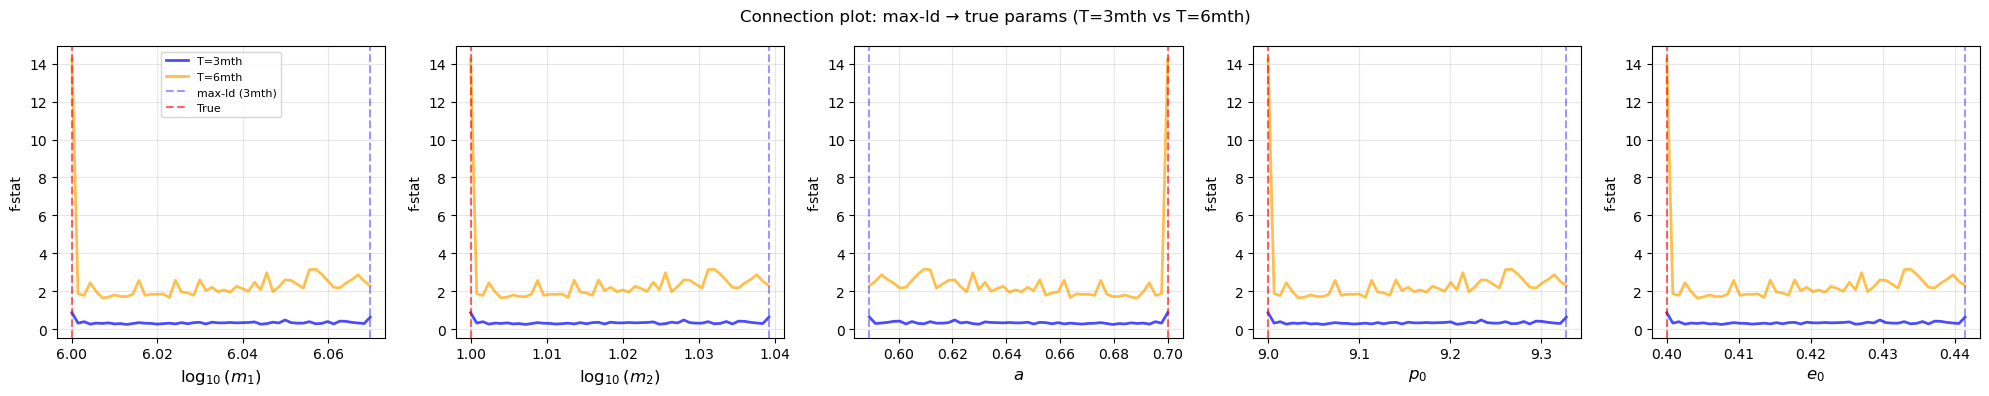

In [22]:
T_6 = 6/12                                                                                                                                                     
waveform_response_6 = build_waveform_response(T=T_6, dt=dt, use_gpu=True, tdi_gen=tdi_gen)
gwf_6 = GravWaveAnalysis(T=T_6, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

loglike_obj_6 = LogLike(
    params=params_star,
    waveform_response=waveform_response_6,
    gwf=gwf_6,
    add_noise=True, 
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)

data_snr_6 = float(gwf_6.rhostat_timemax(loglike_obj_6.signal).get())
print(f'SNR T=6mth (time-max): {data_snr_6:.4f}')

def log_density_6(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a_val, p0_val, e0_val = params[i]
        try: 
            loglike = loglike_obj_6(np.array([
                10**logm1, 10**logm2, a_val, p0_val, e0_val,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes

# Evaluate T=6mth along the same path (maxld_pt → true_pt)
logden_theory_6 = log_density_6(np.array(line_points_proc1).T)
print(f'T=3mth at true: {logden_theory_proc1[-1]:.4f}')
print(f'T=6mth at true: {logden_theory_6[-1]:.4f}')

import matplotlib.pyplot as plt

fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']

for dim in range(5):
    ax = axs_1d[dim]
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-',
            color='blue', alpha=0.7, linewidth=2, label='T=3mth')
    ax.plot(line_points_proc1[dim], logden_theory_6, '-',
            color='orange', alpha=0.7, linewidth=2, label='T=6mth')
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
                alpha=0.4, label='max-ld (3mth)')
    ax.axvline(param_true[dim], color='red', linestyle='--')
# Evaluate T=6mth along the same path (maxld_pt → true_pt)
logden_theory_6 = log_density_6(np.array(line_points_proc1).T)
print(f'T=3mth at true: {logden_theory_proc1[-1]:.4f}')
print(f'T=6mth at true: {logden_theory_6[-1]:.4f}')

import matplotlib.pyplot as plt

fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']

for dim in range(5):
    ax = axs_1d[dim]
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-',
            color='blue', alpha=0.7, linewidth=2, label='T=3mth')
    ax.plot(line_points_proc1[dim], logden_theory_6, '-',
            color='orange', alpha=0.7, linewidth=2, label='T=6mth')
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
                alpha=0.4, label='max-ld (3mth)')
    ax.axvline(param_true[dim], color='red', linestyle='--',
                alpha=0.6, label='True')
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('f-stat', fontsize=10)
    ax.grid(True, alpha=0.3)

axs_1d[0].legend(fontsize=8)
fig_1d.suptitle('Connection plot: max-ld → true params (T=3mth vs T=6mth)', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
logden_theory_6

array([ 2.28529877,  2.52014081,  2.86418738,  2.61388065,  2.42429336,
        2.16461689,  2.20223827,  2.56100713,  2.90303388,  3.16299962,
        3.12813866,  2.15792246,  2.36789106,  2.56574639,  2.59506753,
        2.23038799,  1.96903504,  2.97057136,  2.06783013,  2.46662158,
        1.98889809,  2.13627939,  2.25185455,  1.94266229,  2.06000146,
        1.97323677,  2.19993031,  2.02274727,  2.59128312,  1.77929146,
        1.9061797 ,  1.95103518,  2.57528052,  1.66476406,  1.84803465,
        1.82916836,  1.83228263,  1.77776215,  2.56458849,  1.83986463,
        1.7090915 ,  1.71464121,  1.7988385 ,  1.68558643,  1.63727485,
        1.96995091,  2.44269846,  1.77193714,  1.86021225, 14.23871936])

In [24]:
logden_theory_proc1

array([0.6274657 , 0.29100472, 0.31590655, 0.35044736, 0.40299769,
       0.41534184, 0.26753411, 0.39363526, 0.29474158, 0.27921644,
       0.38741564, 0.30946915, 0.31012297, 0.33652921, 0.47487752,
       0.32062263, 0.36072829, 0.28381457, 0.25312312, 0.37431338,
       0.3443822 , 0.3354832 , 0.32327142, 0.34489114, 0.32297993,
       0.32533192, 0.35914544, 0.26645101, 0.35279969, 0.33570642,
       0.27655107, 0.33667432, 0.26900225, 0.30922334, 0.28148593,
       0.2611255 , 0.29541403, 0.30420751, 0.33629367, 0.28845088,
       0.23996661, 0.28533551, 0.26957487, 0.32495758, 0.29276018,
       0.31390106, 0.25730927, 0.38557795, 0.31028632, 0.86128662])